#### imports

In [8]:
from pprint import pprint

import matplotlib as mpl
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from optuna import trial
from torchmetrics.classification import Accuracy, Precision, Recall

from c2m1_assignment_helper_utils import evaluate_model, extract_attr, get_data_loaders, training_epoch

In [9]:
import c2m1_assignment_helper_utils
import unittests

In [10]:
DEVICE = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"Using Device: {DEVICE}")

Using Device: mps


#### data inspections

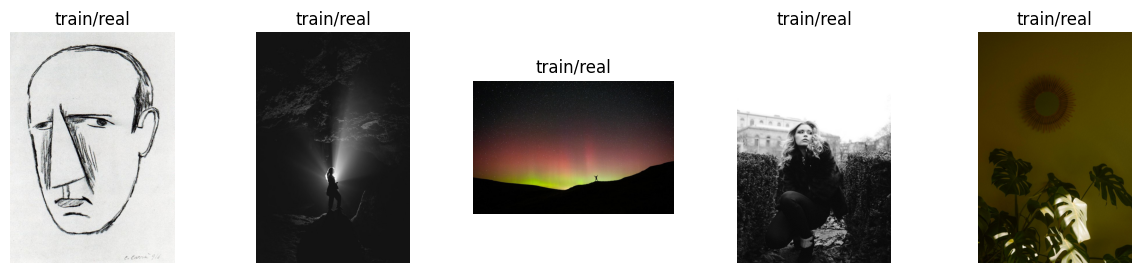

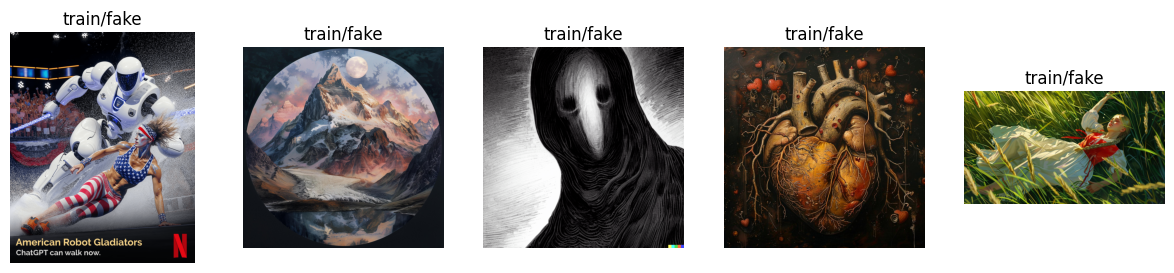

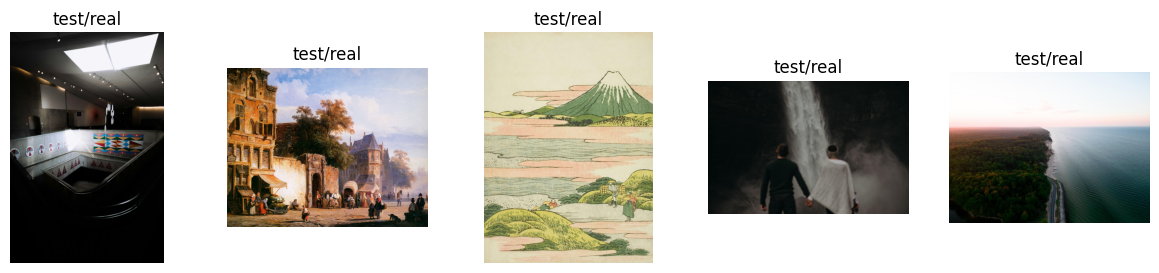

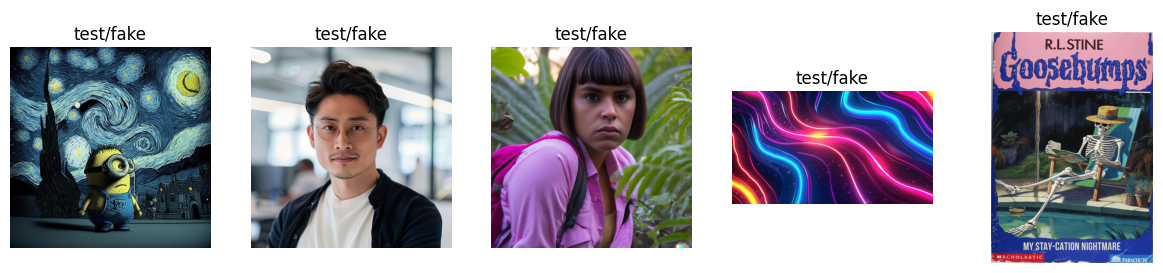

In [11]:
AIvsReal_path = "./AIvsReal_sampled"

# Örnek görselleri görüntüle
for split in ['train', 'test']:
    for category in ['real', 'fake']:
        c2m1_assignment_helper_utils.show_random_images(split, category, AIvsReal_path, num_images=5)

#### building a flexible cnn

In [12]:
class FlexibleCNN(nn.Module):

    def __init__(self, n_layers, n_filters, kernel_sizes, fc_size, dropout_rate, num_classes=2):
        super(FlexibleCNN, self).__init__()

        self.num_classes = num_classes
        self.features = nn.ModuleList()
        in_channels = 3

        for i in range(n_layers):
            out_channels = n_filters[i]
            kernel_size = kernel_sizes[i]

            padding = (kernel_size-1) // 2
            conv_block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
            self.features.append(conv_block)
            in_channels = out_channels

        self.dropout_rate = dropout_rate
        self.fc_size = fc_size

        # classifier will be initialized after calculating flattened size
        self.classifier = None
        self._flattened_size = None

    def _create_classifier(self, flattened_size):

    # creating the classifier using a Sequential container
        self.classifier = nn.Sequential(
            nn.Dropout(p=self.dropout_rate),
            nn.Linear(in_features=flattened_size, out_features=self.fc_size),
            nn.ReLU(),
            nn.Dropout(p=self.dropout_rate),
            nn.Linear(in_features=self.fc_size, out_features=self.num_classes)
        )

    def forward(self, x):

        # apply convolutional feature extraction layers
        for layer in self.features:
            x = layer(x)

        # flatten the output x for the classifier (start_dim=1 to keep the batch dimension)
        x = torch.flatten(x, start_dim=1)

        # Dynamically create classifier if it doesn't exist
        if self.classifier is None:
            self._flattened_size = x.shape[1]
            self._create_classifier(self._flattened_size)

        # Extract the device from the input tensor
        device = x.device

        # Move the classifier to the same device as the input tensor, to ensure compatibility with GPU/CPU
        if self.classifier is not None:
            self.classifier.to(device)

    # Classification
        return self.classifier(x)

In [13]:
# Create the model with specific parameters
n_layers = 3
n_filters = [16, 32, 64]
kernel_sizes = [3, 3, 3]
dropout_rate = 0.5
fc_size = 128

model = FlexibleCNN(
    n_layers=n_layers,
    n_filters=n_filters,
    kernel_sizes=kernel_sizes,
    dropout_rate=dropout_rate,
    fc_size=fc_size,
).to(DEVICE)

resolution = 32
x_sample = torch.randn(1, 3, resolution, resolution).to(DEVICE)  # Example input tensor


# Forward pass through the model
output = model(x_sample)

# print the model features architecture
print(f"FlexibleCNN features architecture:\n{model.features}")

print(f"FlexibleCNN classifier architecture:\n{model.classifier}")

FlexibleCNN features architecture:
ModuleList(
  (0): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
FlexibleCNN classifier architecture:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1)

In [14]:
unittests.exercise_1(FlexibleCNN)

 All tests passed!


#### designing the hyperparameter search space

In [17]:
def design_search_space(trial):

    # CNN Architecture Hyperparameters
    n_layers = trial.suggest_int("n_layers", 1, 3)

    n_filters = [
        trial.suggest_int(f"n_filters_layer{i}", 8, 64, step=8) for i in range(n_layers)
    ]

    kernel_sizes = [
        trial.suggest_int(f"kernel_size_layer{i}", 3, 5, step=2) for i in range(n_layers)
    ]

    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)

    fc_size = trial.suggest_int("fc_size", 64, 512, step=64)

    # Training Hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    resolution = trial.suggest_categorical("resolution", [16,32,64])

    batch_size = trial.suggest_categorical("batch_size", [8, 16])

    return {
        "n_layers": n_layers,
        "n_filters": n_filters,
        "kernel_sizes": kernel_sizes,
        "dropout_rate": dropout_rate,
        "fc_size": fc_size,
        "learning_rate": learning_rate,
        "resolution": resolution,
        "batch_size": batch_size,
    }


#### implementing the optuna objective

In [26]:
def objective_function(trial, device, dataset_path, n_epochs=4, silent=False, test=False):

    # === contruction of model and dataloaders ===

    params = design_search_space(trial)

    # add the transform to resize the images to the specified resolution in params
    transform = transforms.Compose([
        transforms.Resize((params["resolution"], params["resolution"] )),
        transforms.ToTensor(),
    ])

    # define the model using the FlexibleCNN class with the parameters from the trial
    model = FlexibleCNN(
        n_layers=params["n_layers"],
        n_filters=params["n_filters"],
        kernel_sizes=params["kernel_sizes"],
        dropout_rate=params["dropout_rate"],
        fc_size=params["fc_size"],
    )

    # Initialize the dynamic classifier layer by passing a dummy input through the model
    # This ensures all parameters are instantiated before the optimizer is defined
    dummy_input = torch.randn(1, 3, params["resolution"], params["resolution"]).to(device)
    model = model.to(device)
    model(dummy_input)

    train_loader, val_loader = get_data_loaders(transform, params["batch_size"], dataset_path)

    # === optimizer and loss function

    optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"])

    loss_fcn = nn.CrossEntropyLoss()

    # === training the model ===

    model = model.to(device)

    for epoch in range(n_epochs):
        _ = training_epoch(
            model,
            train_loader,
            optimizer,
            loss_fcn,
            device,
            epoch,
            n_epochs,
            silent=silent
        )
    # === evaluation ===

    accuracy = evaluate_model(model, val_loader, device, silent=silent)

    if test:
        extract_attr(trial, transform, model, params)
    return accuracy

In [27]:
fixed_trial = optuna.trial.FixedTrial({
    "n_layers": 2,
    "n_filters_layer0": 16,
    "n_filters_layer1": 32,
    "kernel_size_layer0": 3,
    "kernel_size_layer1": 3,
    "dropout_rate": 0.3,
    "fc_size": 128,
    "learning_rate": 0.001,
    "resolution": 32,
    "batch_size": 16,
})

#_ = helper_utils.run_silent_function(fixed_trial, objective_function)
objective_function(trial=fixed_trial, device=DEVICE, n_epochs=1, dataset_path=AIvsReal_path, silent=False, test=True)

print('\n Some objects from the trial: \n')

print('transform:', fixed_trial.user_attrs['transform'])
print('\n model:', fixed_trial.user_attrs['model'])

Epoch 1/1 - Training:   0%|          | 0/250 [00:00<?, ?it/s]/Users/ramazanyildiz/PycharmProjects/pytorch/.venv/lib/python3.13/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/1 - Training:  18%|█▊        | 45/250 [00:15<00:43,  4.69it/s, loss=0.823]

Epoch [1/1], Step [45/250], Loss: 0.8230


Epoch 1/1 - Training:  36%|███▌      | 90/250 [00:27<00:38,  4.20it/s, loss=0.653]

Epoch [1/1], Step [90/250], Loss: 0.6530


Epoch 1/1 - Training:  54%|█████▍    | 135/250 [00:38<00:30,  3.72it/s, loss=0.606]

...

Epoch 1/1 - Training:  72%|███████▏  | 181/250 [00:50<00:14,  4.81it/s, loss=0.638]

Epoch [1/1], Step [180/250], Loss: 0.6908


Epoch 1/1 - Training:  90%|█████████ | 225/250 [01:01<00:05,  4.29it/s, loss=0.674]

Epoch [1/1], Step [225/250], Loss: 0.6736


Validation Accuracy: 67.50%

 Some objects from the trial: 

transform: Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

 model: FlexibleCNN(
  (features): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, in

In [28]:
unittests.exercise_3(objective_function)

 All tests passed!


In [30]:
storage = "sqlite:///example.db"
study_name = "AIvsReal_optimization"

# Load the study
study = optuna.load_study(study_name=study_name, storage=storage)

In [33]:
# continue with the study, with 2 more trials
n_epochs = 3
study.optimize(lambda trial: objective_function(trial, n_epochs=n_epochs, device=DEVICE, dataset_path=AIvsReal_path), n_trials=2)

Epoch 1/3 - Training:   9%|▉         | 47/500 [00:11<00:55,  8.16it/s, loss=0.543]

Epoch [1/3], Step [45/500], Loss: 0.6369


Epoch 1/3 - Training:  18%|█▊        | 91/500 [00:17<00:51,  7.90it/s, loss=0.776]

Epoch [1/3], Step [90/500], Loss: 0.7223


Epoch 1/3 - Training:  27%|██▋       | 136/500 [00:22<00:40,  8.90it/s, loss=0.558]

...

Epoch 3/3 - Training:  72%|███████▏  | 180/250 [00:42<00:14,  4.89it/s, loss=0.619]

Epoch [3/3], Step [180/250], Loss: 0.6186


Epoch 3/3 - Training:  90%|█████████ | 225/250 [00:52<00:06,  4.14it/s, loss=0.498]

Epoch [3/3], Step [225/250], Loss: 0.4978


Validation Accuracy: 64.20%


In [34]:
# check the k best trials
df_trials = study.trials_dataframe()

# Sort the trials by value (accuracy) in descending order
df_trials.sort_values(by="value", ascending=False, inplace=True)

df_trials

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout_rate,params_fc_size,params_kernel_size_layer0,params_kernel_size_layer1,params_kernel_size_layer2,params_learning_rate,params_n_filters_layer0,params_n_filters_layer1,params_n_filters_layer2,params_n_layers,params_resolution,state
15,15,0.732,2025-12-11 13:32:47.734291,2025-12-11 13:35:37.504316,0 days 00:02:49.770025,16,0.170192,384,5,3.0,NaN,0.000732,32,24.0,NaN,2,16,COMPLETE
6,6,0.715,2025-12-11 13:06:49.671165,2025-12-11 13:09:48.004512,0 days 00:02:58.333347,16,0.134501,384,3,3.0,3.0,0.000135,64,56.0,16.0,3,16,COMPLETE
9,9,0.715,2025-12-11 13:15:41.057247,2025-12-11 13:18:32.186298,0 days 00:02:51.129051,8,0.200294,384,5,3.0,NaN,0.001072,24,16.0,NaN,2,16,COMPLETE
16,16,0.692,2025-12-11 13:35:38.225264,2025-12-11 13:38:26.932308,0 days 00:02:48.707044,16,0.151364,256,5,3.0,NaN,0.000109,32,40.0,NaN,2,16,COMPLETE
1,1,0.690,2025-12-11 12:52:08.460421,2025-12-11 12:55:03.747265,0 days 00:02:55.286844,16,0.395933,128,3,5.0,NaN,0.001220,56,16.0,NaN,2,32,COMPLETE
10,10,0.684,2025-12-11 13:18:32.946655,2025-12-11 13:21:20.491550,0 days 00:02:47.544895,16,0.293843,320,3,3.0,3.0,0.000121,64,64.0,8.0,3,16,COMPLETE
0,0,0.681,2025-12-11 12:49:00.092114,2025-12-11 12:52:07.767483,0 days 00:03:07.675369,8,0.127892,512,3,3.0,NaN,0.002208,16,16.0,NaN,2,64,COMPLETE
21,21,0.681,2025-12-11 13:59:57.784662,2025-12-11 14:02:56.033982,0 days 00:02:58.249320,8,0.198983,384,5,3.0,NaN,0.001234,24,24.0,NaN,2,16,COMPLETE
18,18,0.679,2025-12-11 13:41:19.146434,2025-12-11 13:44:13.993472,0 days 00:02:54.847038,16,0.257056,320,5,NaN,NaN,0.000491,32,NaN,NaN,1,64,COMPLETE
8,8,0.674,2025-12-11 13:12:40.715342,2025-12-11 13:15:40.304773,0 days 00:02:59.589431,8,0.164594,448,3,3.0,5.0,0.000695,16,40.0,56.0,3,64,COMPLETE


In [35]:
k = 5
# Get the top k trials
best_k_trials = df_trials.head(k)
best_k_trials

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout_rate,params_fc_size,params_kernel_size_layer0,params_kernel_size_layer1,params_kernel_size_layer2,params_learning_rate,params_n_filters_layer0,params_n_filters_layer1,params_n_filters_layer2,params_n_layers,params_resolution,state
15,15,0.732,2025-12-11 13:32:47.734291,2025-12-11 13:35:37.504316,0 days 00:02:49.770025,16,0.170192,384,5,3.0,NaN,0.000732,32,24.0,NaN,2,16,COMPLETE
6,6,0.715,2025-12-11 13:06:49.671165,2025-12-11 13:09:48.004512,0 days 00:02:58.333347,16,0.134501,384,3,3.0,3.0,0.000135,64,56.0,16.0,3,16,COMPLETE
9,9,0.715,2025-12-11 13:15:41.057247,2025-12-11 13:18:32.186298,0 days 00:02:51.129051,8,0.200294,384,5,3.0,NaN,0.001072,24,16.0,NaN,2,16,COMPLETE
16,16,0.692,2025-12-11 13:35:38.225264,2025-12-11 13:38:26.932308,0 days 00:02:48.707044,16,0.151364,256,5,3.0,NaN,0.000109,32,40.0,NaN,2,16,COMPLETE
1,1,0.690,2025-12-11 12:52:08.460421,2025-12-11 12:55:03.747265,0 days 00:02:55.286844,16,0.395933,128,3,5.0,NaN,0.001220,56,16.0,NaN,2,32,COMPLETE


In [36]:
def get_trainable_params(model):

    total_trainable_params = 0

    model_parameters = model.parameters()

    for param in model_parameters:
        if param.requires_grad:
            total_trainable_params += param.numel()

    return total_trainable_params

In [37]:
n_layers = 3
n_filters = [16, 32, 64]
kernel_sizes = [3, 3, 3]
dropout_rate = 0.5
fc_size = 128

model = FlexibleCNN(
    n_layers=n_layers,
    n_filters=n_filters,
    kernel_sizes=kernel_sizes,
    dropout_rate=dropout_rate,
    fc_size=fc_size,
)

# Run a dummy pass to create the classifier layers
# otherwise get_trainable_params will only count the feature extractor
resolution = 32
dummy_input = torch.randn(1, 3, resolution, resolution)
model(dummy_input)

print("Total trainable parameters:", get_trainable_params(model))

Total trainable parameters: 155266


In [38]:
unittests.exercise_4(get_trainable_params)

 All tests passed!


In [ ]:
def add